In [1]:
"""Imports."""

from matplotlib import pyplot as plt
from pathlib import Path
import json
import numpy as np
import torch
from python_utils.configs import build_from_config

import sys
sys.path.append("../..")
sys.path.append("../../training")

# Matplotlib settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.dpi'] = 300

In [2]:
"""Load model from snapshot."""

_LOG_DIR = Path("../../training/logs/24")
config_path = _LOG_DIR / "config.json"
model_snapshot_path = _LOG_DIR / "model_snapshot.pth"
config = json.load(open(config_path))
model_config = config["kwargs"]["model"]
model = build_from_config.build_from_config(model_config)
model.load_state_dict(torch.load(model_snapshot_path))

<All keys matched successfully>

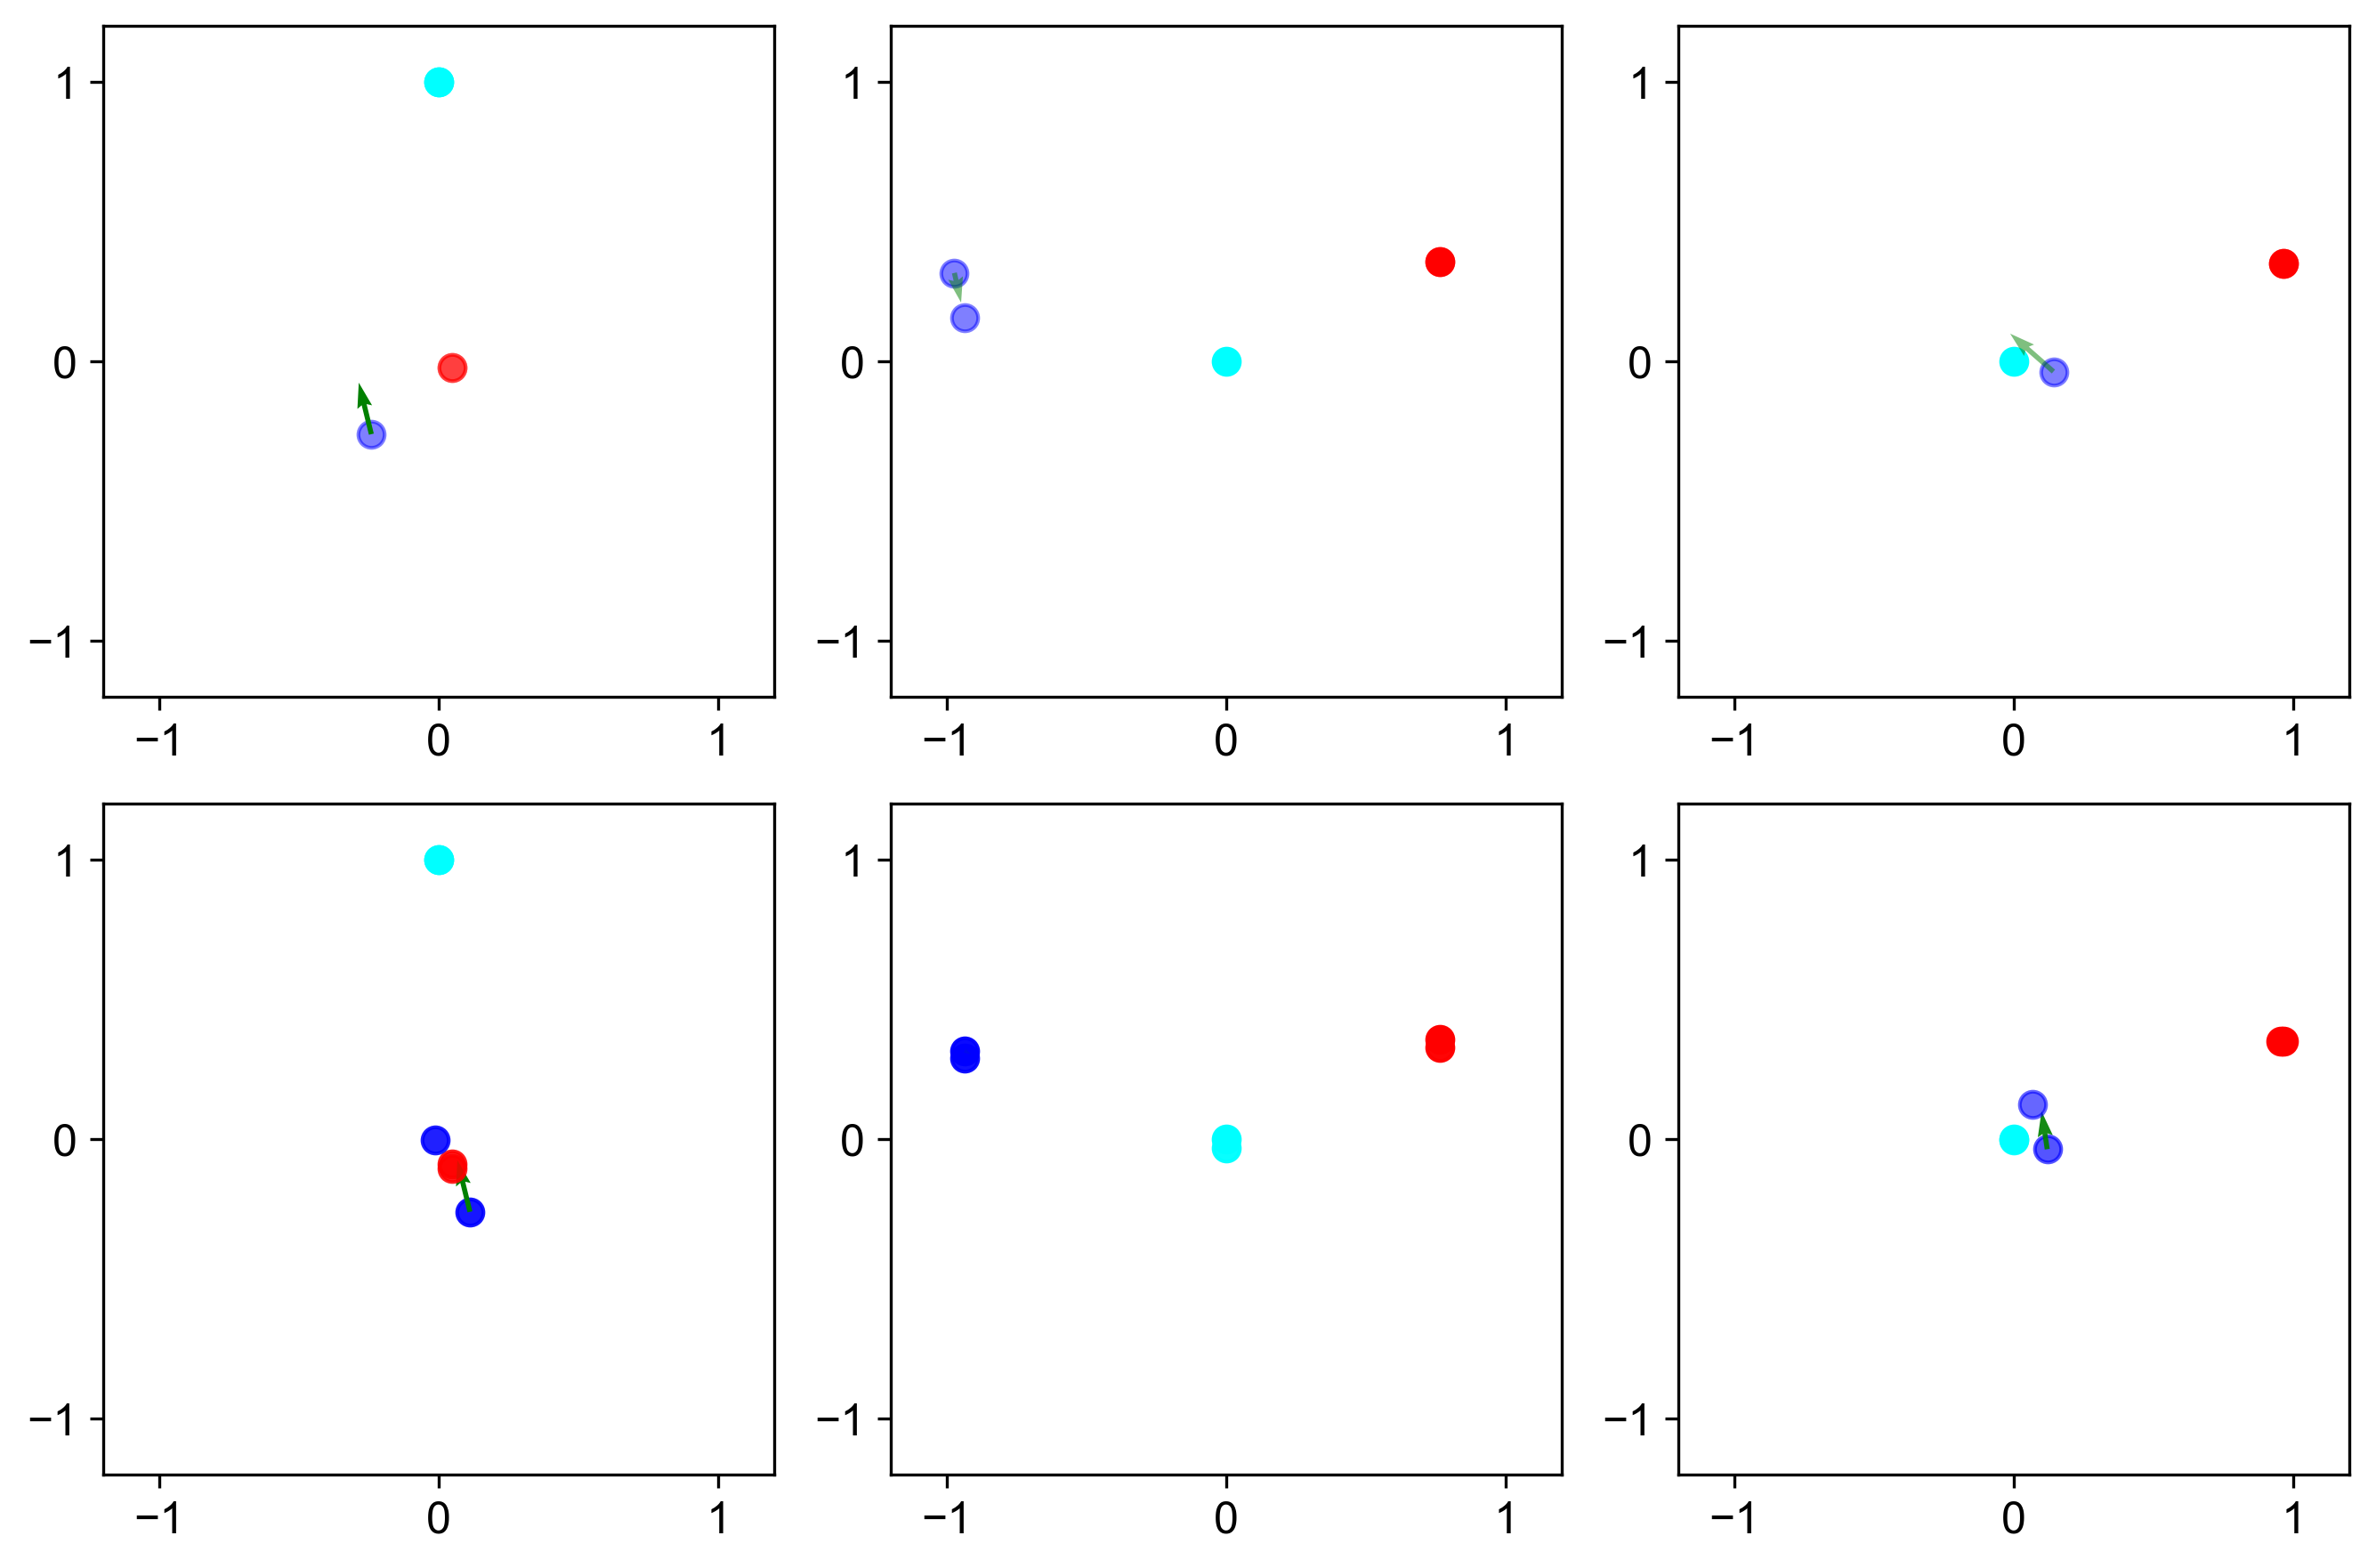

In [29]:
"""Plot random batch."""

_N_PLOT = 3

agent = model.dataset.agent
state, snr, duration = model.dataset.get_batch()
# state_noised = state * (1 + snr * torch.randn_like(state))
model_state_per_step, model_snr_per_step = model.forward(state, snr, duration)


def _plot_observation(ax, agent, obs, obs_snr, action=None, action_snr=None):
    components = agent.environment.observation_to_components(obs)
    components_snr = agent.environment.observation_to_components(obs_snr)
    hand = components["hand"]
    hand_alpha = float(np.mean(components_snr["hand"]))# > 0.5)
    obj = components["object"]
    obj_alpha = float(np.mean(components_snr["object"]))# > 0.5)
    feedback = components["feedback"]
    feedback_snr = components_snr["feedback"]
    ax.scatter(hand[0], hand[1], c="blue", alpha=hand_alpha, s=50)
    ax.scatter(obj[0], obj[1], c="red", alpha=obj_alpha, s=50)
    ax.scatter(0, feedback, c="cyan", alpha=feedback_snr, s=50)
    if action is not None:
        action_alpha = float(np.mean(action_snr))# > 0.5)
        ax.quiver(
            hand[0], hand[1],
            action[0], action[1],
            angles='xy', scale_units='xy', scale=1.5, color='green', alpha=action_alpha,
        )

def _plot_state(ax, agent, plot_state, plot_snr):
    obs_start = plot_state[0:agent.observation_dim]
    obs_start_snr = plot_snr[0:agent.observation_dim]
    action_start = plot_state[agent.observation_dim:agent.observation_dim + agent.action_dim]
    action_start_snr = plot_snr[agent.observation_dim:agent.observation_dim + agent.action_dim]
    obs_end = plot_state[agent.observation_dim + agent.action_dim:]
    obs_end_snr = plot_snr[agent.observation_dim + agent.action_dim:]
    _plot_observation(ax, agent, obs_start, obs_snr=obs_start_snr, action=action_start, action_snr=action_start_snr)
    _plot_observation(ax, agent, obs_end, obs_snr=obs_end_snr)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

fig, axes = plt.subplots(2, _N_PLOT, figsize=(3 * _N_PLOT, 6))
for i in range(_N_PLOT):
    # Plot ground truth
    gt_state = state[i].cpu().numpy()
    gt_snr = snr[i].cpu().numpy()
    _plot_state(axes[0, i], agent, gt_state, gt_snr)

    # Plot model
    model_state = model_state_per_step[-1, i].detach().cpu().numpy()
    model_snr = model_snr_per_step[-1, i].detach().cpu().numpy()
    _plot_state(axes[1, i], agent, model_state, model_snr)

fig.tight_layout()